# Import des modules

In [ ]:
pip install pandas

In [ ]:
pip install matplotlib

In [ ]:

pip install seaborn

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.model_selection import ParameterGrid

# Chargement des données

In [7]:
dataset = pd.read_csv('https://raw.githubusercontent.com/IngridFi70/Projet06/main/data/dataset.csv')

# Modélisation 

### Préparation des features pour la modélisation

#### 1. Avec outliers dans les données test uniquement

##### Split du dataset en 2 : un avec les outliers, l'autre sans les outliers

In [10]:
# Séparer les outliers et les non-outliers
df_outliers = dataset[dataset['outlier'] == True]
df_clean = dataset[dataset['outlier'] == False]

##### Séparer les features et la target

In [11]:
# Séparer les features et la target
X_clean = df_clean.drop(columns=['SiteEnergyUse(kBtu)', 'outlier'])
y_clean = df_clean['SiteEnergyUse(kBtu)']
X_outliers = df_outliers.drop(columns=['SiteEnergyUse(kBtu)', 'outlier'])
y_outliers = df_outliers['SiteEnergyUse(kBtu)']

##### Séparer les données train des données test

In [12]:
# Faire un split sur les non-outliers pour le train/test
X_train1, X_clean_test, y_train1, y_clean_test = train_test_split(
X_clean, y_clean, test_size=0.2, random_state=42
)

# Ajouter les outliers au jeu de test
X_test1 = pd.concat([X_clean_test, X_outliers])
y_test1 = pd.concat([y_clean_test, y_outliers])

# Réinitialiser les index
X_train1 = X_train1.reset_index(drop=True)
y_train1 = y_train1.reset_index(drop=True)
X_test1 = X_test1.reset_index(drop=True)
y_test1 = y_test1.reset_index(drop=True)

In [13]:
X_train1.columns

Index(['Neighborhood', 'NumberofFloors', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'ratio_steam',
       'ratio_electricity', 'ratio_gas', 'flag_datacenter', 'flag_laboratory',
       'flag_office', 'flag_downtown', 'flag_greatduw', 'flag_lakeu'],
      dtype='object')

#### 2. Avec les outliers aléatoirement distribués dans les données train et test

##### Séparer les features et la target

In [101]:
# Séparer les features et la target
X_data2 = dataset.drop(columns=['SiteEnergyUse(kBtu)', 'outlier'])
y_data2 = dataset['SiteEnergyUse(kBtu)']

##### Séparer les données train des données test

In [102]:
# Faire un split sur les non-outliers pour le train/test
X_train2, X_test2, y_train2, y_test2 = train_test_split(
X_data2, y_data2, test_size=0.2, random_state=42
)

# Réinitialiser les index
X_train2 = X_train2.reset_index(drop=True)
y_train2 = y_train2.reset_index(drop=True)
X_test2 = X_test2.reset_index(drop=True)
y_test2 = y_test2.reset_index(drop=True)

In [103]:
X_train2.columns

Index(['Neighborhood', 'NumberofFloors', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'ratio_steam',
       'ratio_electricity', 'ratio_gas', 'flag_datacenter', 'flag_laboratory',
       'flag_office', 'flag_downtown', 'flag_greatduw', 'flag_lakeu'],
      dtype='object')

### Comparaison de différents modèles supervisés

### Régression Linéaire

In [228]:
# model
model = LinearRegression()

# cross val
scores = cross_validate(model, X_train1, y_train1, cv=5, scoring='r2', return_train_score=True)

# print score du cross val
print(f"Model: {model}\n")
print(" Validation croisée :")
print(f"  Mean train R2: {np.mean(scores['train_score']):.3f}")
print(f"  Mean test R2:  {np.mean(scores['test_score']):.3f}\n")

# fit
model.fit(X_train1, y_train1)

# predict
y_pred_test1 = model.predict(X_test1)

# print score du predict
print(" Prédiction vs réel :")
print(f"  MSE: {mean_squared_error(y_test1, y_pred_test1):.3f}")
print(f"  MAE: {mean_absolute_error(y_test1, y_pred_test1):.3f}")
print(f"  MAPE: {mean_absolute_percentage_error(y_test1, y_pred_test1):.3f}")
print(f"  R2: {r2_score(y_test1, y_pred_test1):.3f}")

Model: LinearRegression()

 Validation croisée :
  Mean train R2: 0.357
  Mean test R2:  0.334

 Prédiction vs réel :
  MSE: 115556857930462.453
  MAE: 5818174.382
  MAPE: 1.050
  R2: 0.479


In [229]:
model.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

## Création de fonctions

In [239]:
# Evaluer un modèle avec le jeu de données 1
def run_model1(model):
    scores = cross_validate(model, X_train1, y_train1, cv=5, scoring='r2', return_train_score=True) # cross val
    print(f"Modèle: {model}\n")
    print(f"Paramètres: {model.get_params()}\n")
    print(" Validation croisée :")
    print(f"  Mean train R2: {np.mean(scores['train_score']):.3f}")
    print(f"  Mean test R2:  {np.mean(scores['test_score']):.3f}\n") # print score du cross val
    model.fit(X_train1, y_train1) # fit
    y_pred_test1 = model.predict(X_test1) # predict
    print(" Prédiction vs réel :")
    print(f"  MSE: {mean_squared_error(y_test1, y_pred_test1):.3f}")
    print(f"  MAE: {mean_absolute_error(y_test1, y_pred_test1):.3f}")
    print(f"  MAPE: {mean_absolute_percentage_error(y_test1, y_pred_test1):.3f}")
    print(f"  R2: {r2_score(y_test1, y_pred_test1):.3f}") # print score du predict

In [ ]:
# Evaluer un modèle avec le jeu de données 2
def run_model2(model):
    scores = cross_validate(model, X_train2, y_train2, cv=5, scoring='r2', return_train_score=True) # cross val
    print(f"Modèle: {model}\n")
    print(f"Paramètres: {model.get_params()}\n")
    print(" Validation croisée :")
    print(f"  Mean train R2: {np.mean(scores['train_score']):.3f}")
    print(f"  Mean test R2:  {np.mean(scores['test_score']):.3f}\n") # print score du cross val
    model.fit(X_train2, y_train2) # fit
    y_pred_test2 = model.predict(X_test2) # predict
    print(" Prédiction vs réel :")
    print(f"  MSE: {mean_squared_error(y_test2, y_pred_test2):.3f}")
    print(f"  MAE: {mean_absolute_error(y_test2, y_pred_test2):.3f}")
    print(f"  MAPE: {mean_absolute_percentage_error(y_test2, y_pred_test2):.3f}")
    print(f"  R2: {r2_score(y_test2, y_pred_test2):.3f}") # print score du predict

In [241]:
# Tester le modèle 1
run_model1(LinearRegression())

Modèle: LinearRegression()

Paramètres: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}

 Validation croisée :
  Mean train R2: 0.357
  Mean test R2:  0.334

 Prédiction vs réel :
  MSE: 115556857930462.453
  MAE: 5818174.382
  MAPE: 1.050
  R2: 0.479


In [242]:
# Tester le modèle 2
run_model2(LinearRegression())

Modèle: LinearRegression()

Paramètres: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}

 Validation croisée :
  Mean train R2: 0.698
  Mean test R2:  0.669

 Prédiction vs réel :
  MSE: 43592178047348.773
  MAE: 3260863.817
  MAPE: 1.841
  R2: 0.500


## Tests sur plusieurs modèles

In [200]:
# Liste des modèles à tester
models = {
    'reg': LinearRegression(),
    'ridge': Ridge(),
    'RandomForest': RandomForestRegressor(),
    'svr': SVR(),
    'dtr': DecisionTreeRegressor(),
    'DM': DummyRegressor(),
    'GradientBoosting': GradientBoostingRegressor(),
    'EN': ElasticNet()
}

In [243]:
for name, model in models.items():
    run_model1(model)
    print("-----------")

Modèle: LinearRegression()

Paramètres: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}

 Validation croisée :
  Mean train R2: 0.357
  Mean test R2:  0.334

 Prédiction vs réel :
  MSE: 115556857930462.453
  MAE: 5818174.382
  MAPE: 1.050
  R2: 0.479
-----------
Modèle: Ridge()

Paramètres: {'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}

 Validation croisée :
  Mean train R2: 0.355
  Mean test R2:  0.334

 Prédiction vs réel :
  MSE: 116422989167327.578
  MAE: 5835276.946
  MAPE: 1.054
  R2: 0.476
-----------
Modèle: RandomForestRegressor()

Paramètres: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators

Avec les hyperparamètres par défaut et les données du split 1, RandomForestRegressor() et GradientBoostingRegressor() sont les modèles qui présentent pour l'instant les meilleures performances parmi les modèles testés.

In [175]:
for name, model in models.items():
    run_model2(model)
    print("-----------")

Modèle: LinearRegression()

 Validation croisée :
  Mean train R2: 0.698
  Mean test R2:  0.669

 Prédiction vs réel :
  MSE: 43592178047348.773
  MAE: 3260863.817
  MAPE: 1.841
  R2: 0.500
-----------
Modèle: Ridge()

 Validation croisée :
  Mean train R2: 0.694
  Mean test R2:  0.665

 Prédiction vs réel :
  MSE: 43388689487369.156
  MAE: 3276221.329
  MAPE: 1.887
  R2: 0.503
-----------
Modèle: RandomForestRegressor()

 Validation croisée :
  Mean train R2: 0.954
  Mean test R2:  0.665

 Prédiction vs réel :
  MSE: 29190154344904.801
  MAE: 2727976.230
  MAPE: 0.971
  R2: 0.665
-----------
Modèle: SVR()

 Validation croisée :
  Mean train R2: -0.134
  Mean test R2:  -0.136

 Prédiction vs réel :
  MSE: 101147728000540.891
  MAE: 4820960.737
  MAPE: 1.633
  R2: -0.160
-----------
Modèle: DecisionTreeRegressor()

 Validation croisée :
  Mean train R2: 1.000
  Mean test R2:  0.489

 Prédiction vs réel :
  MSE: 73780485484979.438
  MAE: 3920549.901
  MAPE: 1.038
  R2: 0.154
-----------


Avec les hyperparamètres par défaut et les données du split , RandomForestRegressor() et GradientBoostingRegressor() sont aussi les modèles qui présentent pour l'instant les meilleures performances parmi les modèles testés.

### Recherche de la meilleure combinaison d'hyperparamètres

In [409]:
# liste de grilles spécialisées en fonction du noyau pour le modèle SVR :
param_svr = [
    {'kernel': ['linear'], 'C': [0.1, 1.0, 3.0], 'epsilon': [0.1, 0.5], 'max_iter': [5000]},
    {'kernel': ['rbf'], 'C': [0.1, 1.0, 3.0], 'gamma': ['scale', 'auto'], 'epsilon': [0.1, 0.5], 'max_iter': [5000]},
    {'kernel': ['poly'], 'C': [0.1, 1.0, 3.0], 'degree': [2, 3], 'coef0': [0.0], 'gamma': ['scale', 'auto'], 'epsilon': [0.1, 0.5], 'max_iter': [5000]}
]


# liste des hyperparamètres à tester pour les modèles :
parameters = {
    
    
    "LinearRegression":{
        "hyperparametres":{
            'copy_X': [True],
            'fit_intercept': [True, False],
            'n_jobs': [None],
            'positive': [True, False],
            'tol': [1e-04, 1e-05,1e-06]
        },
        "modele":LinearRegression()
    },
    
    
    "Ridge":{
        "hyperparametres":{
            'alpha': [1.0, 3.0, 10.0], 
            'copy_X': [True], 
            'fit_intercept': [True, False], 
            'max_iter': [None, 2, 5, 10], 
            'positive': [False], 
            'random_state': [42], 
            'solver': ['auto','svd','cholesky','sparse_cg'], 
            'tol': [0.0001]
        },
        "modele":Ridge()
    },
    
    "DecisionTreeRegressor":{
        "hyperparametres":{
            'ccp_alpha': [0.0], 
            'criterion': ['absolute_error', 'squared_error','poisson', 'friedman_mse'], 
            'max_depth': [None], 
            'max_features': [None, 10], 
            'max_leaf_nodes': [None], 
            'min_impurity_decrease': [0.0], 
            'min_samples_leaf': [1, 3, 5], 
            'min_samples_split': [3, 5, 10], 
            'min_weight_fraction_leaf': [0.0, 0.2], 
            'monotonic_cst': [None], 
            'random_state': [42], 
            'splitter': ['best']
        },
        "modele":DecisionTreeRegressor()
    },
    
     "DummyRegressor":{
        "hyperparametres":{
            'constant': [None], 
            'quantile': [None], 
            'strategy': ['mean']
        },
        "modele":DummyRegressor()
    },
    
     "ElasticNet":{
        "hyperparametres":{
            'alpha': [1.0, 3.0, 10.0], 
            'copy_X': [True], 
            'fit_intercept': [True], 
            'l1_ratio': [0.5], 
            'max_iter': [1500, 2000, 10000, 20000],
            'positive': [False], 
            'precompute': [False], 
            'random_state': [42], 
            'selection': ['cyclic','random'], 
            'tol': [0.001, 0.0001, 0.00001], 
            'warm_start': [False]
        },
        "modele":ElasticNet()
    },
    
    "RandomForest":{
        "hyperparametres":{
            'n_estimators': [100, 200], # hyperparamètre important
            'criterion': ['absolute_error', 'squared_error','poisson', 'friedman_mse'],
            'max_depth': [4, 5, 6], # hyperparamètre important
            'min_samples_split': [3, 5, 10], # hyperparamètre important (en fonction du nombre de lignes)
            'min_samples_leaf': [1, 3, 5], # hyperparamètre important (en fonction du nombre de lignes)
            'max_features': [None, 10], # hyperparamètre important
            #'bootstrap': [True, False],
            'random_state': [42],
            #'n_jobs': [None, 1, 2, -1],
            'verbose': [0],
            'max_samples': [None]
        },
        "modele":RandomForestRegressor()
    },
    "GradientBoosting": {
         "hyperparametres":{
            'loss' : ['squared_error', 'quantile'], #— fonction de perte à optimiser ("squared_error", "huber", "quantile")
            'learning_rate' : [0.1, 1.0, 2.0], #— taux d’apprentissage qui contrôle la contribution de chaque arbre
            'n_estimators': [100, 200],
            'subsample' : [1.0], #— fraction des échantillons utilisée pour construire chaque arbre (bootstrap sans remise si <1.0)
            'criterion': ['friedman_mse', 'squared_error'],#criterion : "friedman_mse" ("friedman_mse", "squared_error", "mse")
            'min_samples_split': [3, 5, 10], 
            'min_samples_leaf': [1, 3], 
            'min_weight_fraction_leaf' : [0.0], #— fraction minimale du poids total d’échantillons dans une feuille
            'max_depth': [5, 6],
            'min_impurity_decrease' : [0.0], #— seuil de diminution minimale d’impureté pour scinder
            'init': [None], #— estimateur initial (par défaut, constante)
            'random_state': [42],
            'max_features': [None],
            'alpha' : [0.9], #— quantile pour la perte quantile (si loss='quantile')
            'verbose': [0],
            'max_leaf_nodes': [None], #— nombre maximum de feuilles par arbre
            'warm_start': [False], #— réutilise l’entraînement précédent pour ajouter des arbres
            'validation_fraction' : [0.1], #— fraction des données réservée pour la validation (early stopping)
            'n_iter_no_change' : [None], #— nombre d’itérations sans amélioration avant arrêt (early stopping)
            'tol' : [1e-4], #— tolérance pour l’arrêt anticipé
            'ccp_alpha' : [0.0] #— paramètre de complexité pour l’élagage (post-pruning)
        },
        "modele":GradientBoostingRegressor()
    },
    
    "SVR": {
        "hyperparametres": param_svr,
        "modele": SVR()
    }
}

In [410]:
parameters.keys()

dict_keys(['LinearRegression', 'Ridge', 'DecisionTreeRegressor', 'DummyRegressor', 'ElasticNet', 'RandomForest', 'GradientBoosting', 'SVR'])

In [411]:
# Nombre de combinaisons à tester
for model in parameters.keys():
    parameter = parameters[model]["hyperparametres"]
    grid = list(ParameterGrid(parameter))
    print(f"Nombre total de combinaisons {model}: {len(grid)}")

Nombre total de combinaisons LinearRegression: 12
Nombre total de combinaisons Ridge: 96
Nombre total de combinaisons DecisionTreeRegressor: 144
Nombre total de combinaisons DummyRegressor: 1
Nombre total de combinaisons ElasticNet: 72
Nombre total de combinaisons RandomForest: 432
Nombre total de combinaisons GradientBoosting: 288
Nombre total de combinaisons SVR: 42


In [412]:
# Créer et entraîner le GridSearchCV
results = {}
for model in parameters.keys():
    print(f"{50*'*'} modèle traité : {model} {50*'*'}")
    grid_search = GridSearchCV(estimator=parameters[model]["modele"], param_grid=parameters[model]["hyperparametres"], cv=5, n_jobs=-1)
    grid_search.fit(X_train2, y_train2) # Entrainer le GridSearchCV aux données train
    print("Best Hyperparameters: ", grid_search.best_params_)# Afficher les meilleurs hyperparamètres et leur performance
    print("Best Accuracy Score: {:.2f}%".format(grid_search.best_score_ * 100))
    best_model = grid_search.best_estimator_ # configuration optimale
    best_param = grid_search.best_params_ # paramètres optimaux
    best_score = grid_search.best_score_ * 100 # meilleur score de performance
    test_accuracy = (best_model.score(X_test2, y_test2))*100 # Evaluer le modèle optimal avec les données test 2
    print("Test Accuracy data2: {:.2f}%".format(test_accuracy))
    test_accuracy1 = (best_model.score(X_test1, y_test1))*100 # Evaluer le modèle optimal avec les données test 1
    print("Test Accuracy data1: {:.2f}%".format(test_accuracy1))
    results[model]= {"best_config":best_model,"parametres":best_param,"score":"{:.2f}%".format(best_score),"test_accuracy":"{:.2f}%".format(test_accuracy),"test_accuracy1":"{:.2f}%".format(test_accuracy1)}

************************************************** modèle traité : LinearRegression **************************************************
Best Hyperparameters:  {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 0.0001}
Best Accuracy Score: 66.92%
Test Accuracy data2: 50.03%
Test Accuracy data1: 60.38%
************************************************** modèle traité : Ridge **************************************************
Best Hyperparameters:  {'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': 42, 'solver': 'svd', 'tol': 0.0001}
Best Accuracy Score: 66.48%
Test Accuracy data2: 50.26%
Test Accuracy data1: 59.85%
************************************************** modèle traité : DecisionTreeRegressor **************************************************
Best Hyperparameters:  {'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': None, 'max_features': 10, 'max_leaf_nodes': None, 'min_impurity_decr

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

Best Hyperparameters:  {'C': 3.0, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'poly', 'max_iter': 5000}
Best Accuracy Score: -7.44%
Test Accuracy data2: -13.64%
Test Accuracy data1: -39.08%


In [413]:
from pprint import pprint

for model in parameters.keys():
    print(f"{10*'*'} modèle : {model} {10*'*'}")
    pprint(results[model])
    print()

********** modèle : LinearRegression **********
{'best_config': LinearRegression(tol=0.0001),
 'parametres': {'copy_X': True,
                'fit_intercept': True,
                'n_jobs': None,
                'positive': False,
                'tol': 0.0001},
 'score': '66.92%',
 'test_accuracy': '50.03%',
 'test_accuracy1': '60.38%'}

********** modèle : Ridge **********
{'best_config': Ridge(random_state=42, solver='svd'),
 'parametres': {'alpha': 1.0,
                'copy_X': True,
                'fit_intercept': True,
                'max_iter': None,
                'positive': False,
                'random_state': 42,
                'solver': 'svd',
                'tol': 0.0001},
 'score': '66.48%',
 'test_accuracy': '50.26%',
 'test_accuracy1': '59.85%'}

********** modèle : DecisionTreeRegressor **********
{'best_config': DecisionTreeRegressor(criterion='absolute_error', max_features=10,
                      min_samples_leaf=5, min_samples_split=3, random_state=42),
 

Le meilleur modèle reste le **Random Forest**.

### Optimisation et interprétation du modèle

In [415]:
selected_model = RandomForestRegressor(
    criterion = 'squared_error',
    max_depth = 6,
    max_features = 10,
    max_samples = None,
    min_samples_leaf = 1,
    min_samples_split = 10,
    n_estimators = 200,
    random_state = 42,
    verbose = 0)
selected_model.fit(X_train2, y_train2)


,n_estimators,200
,criterion,'squared_error'
,max_depth,6
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Feature importance

Text(0.5, 0, 'Feature Importance')

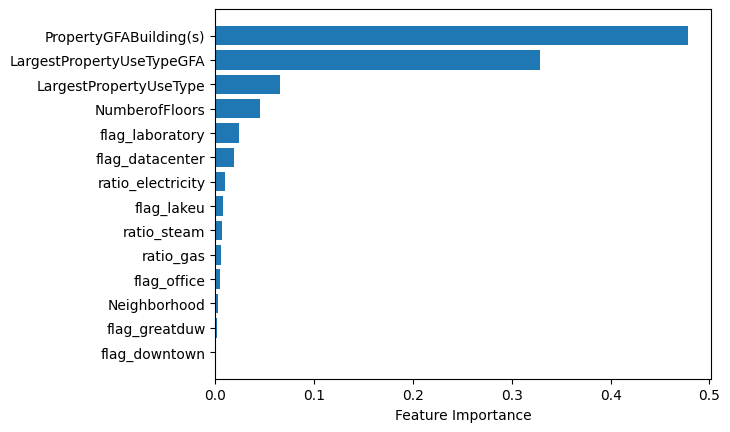

In [416]:
from sklearn.inspection import permutation_importance

sort = selected_model.feature_importances_.argsort()

plt.barh(X_train2.columns[sort], selected_model.feature_importances_[sort])

plt.xlabel("Feature Importance")

Les variables les plus influentes pour la prédiction sont la surface bâtiment et la surface utilisée pour l'usage principal du bâtiment.

In [417]:
import pickle

In [419]:
# save the model to disk
filename = '/Users/ingrid/Documents/OpenClassrooms/PROJETS/model/finalized_model.sav'
pickle.dump(selected_model, open(filename, 'wb')) # wb = en écriture

# (tests)

## Régression Linéaire

In [77]:
reg = LinearRegression()
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
y_pred_test_reg = reg.predict(X_test)

In [79]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print(f"RMSE: {mean_squared_error(y_test, y_pred_test_reg)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test_reg)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test_reg)}")
print(f"R2: {r2_score(y_test, y_pred_test_reg)}")
print(f"score: {reg.score(X_test, y_test)}")

RMSE: 115556857930462.45
MAE: 5818174.382200218
MAPE: 1.0502953139831828
R2: 0.4794788551001091
score: 0.4794788551001091


In [80]:
print(reg.coef_)

[-1.60984177e+04  9.87906474e+04  2.99698689e+01  5.94662653e+04
  1.17256040e+01 -8.45004365e+05 -2.08237305e+06 -9.99603826e+05
  1.44354999e-08  6.42304707e+06  4.17698774e+05 -9.94615020e+04
 -4.62693800e+05  3.35828369e+05]


## SVR

In [83]:
svr=SVR()
svr.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [84]:
y_pred_test_svr = svr.predict(X_test)

In [85]:
print(f"RMSE: {mean_squared_error(y_test, y_pred_test_svr)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test_svr)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test_svr)}")
print(f"R2: {r2_score(y_test, y_pred_test_svr)}")
print(f"score: {svr.score(X_test, y_test)}")

RMSE: 339994493294112.2
MAE: 11209034.570925709
MAPE: 1.3108538845132325
R2: -0.5314913028840373
score: -0.5314913028840373


## Random Forest Regressor

In [87]:
rfr=RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
y_pred_test_rfr = rfr.predict(X_test)

In [89]:
print(f"RMSE: {mean_squared_error(y_test, y_pred_test_rfr)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test_rfr)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test_rfr)}")
print(f"R2: {r2_score(y_test, y_pred_test_rfr)}")
print(f"score: {rfr.score(X_test, y_test)}")

RMSE: 232387711708890.12
MAE: 8218276.882301305
MAPE: 1.2759286901601399
R2: -0.046780952041529655
score: -0.046780952041529655


## Decision Tree Regressor

In [90]:
dtr=DecisionTreeRegressor(random_state=42)
dtr.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [91]:
y_pred_test_dtr = dtr.predict(X_test)

In [92]:
print(f"RMSE: {mean_squared_error(y_test, y_pred_test_dtr)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test_dtr)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test_dtr)}")
print(f"R2: {r2_score(y_test, y_pred_test_dtr)}")
print(f"score: {dtr.score(X_test, y_test)}")

RMSE: 234903499215607.6
MAE: 8450839.51354346
MAPE: 1.403231570241456
R2: -0.058113214070577124
score: -0.058113214070577124


# SUITE

In [ ]:
# CODE COMPARAISON DES MODELES

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE